# Projeto P2 — Mosaico de imagens aéreas: bairro de Perdizes (SP)

**Disciplina:** Aprendizagem de Máquina — PUC-SP
**Autor de referência:** Prof. Dr. Rooney Coelho
**Objetivo deste notebook:** demonstrar, de ponta a ponta, como **gerar programaticamente um mosaico de imagens aéreas** cobrindo um bairro inteiro de São Paulo (Perdizes) para servir de base para anotação e treinamento de um detector de objetos (helipontos, piscinas em cobertura etc.).

---

## Fonte das imagens

A intenção pedagógica original era usar o **GeoSampa** (Prefeitura de SP). Porém, verificando o serviço WMS público em `wms.geosampa.prefeitura.sp.gov.br/geoserver/geoportal/wms`, observou-se que **apenas camadas vetoriais** (articulações, redes, zoneamento etc.) são expostas — as ortofotos raster ficam atrás do fluxo do portal e não estão acessíveis diretamente por `GetMap` anônimo.

Como alternativa estável, com **licença permissiva para uso educacional** (com atribuição), este notebook usa o serviço público de tiles **ESRI World Imagery**:

`https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}`

> *Atribuição obrigatória:* "Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community."

O mesmo padrão de código (computar tiles XYZ a partir de um bbox e baixá-los em lote) vale para qualquer serviço XYZ — inclusive GeoSampa, se/quando o aluno conseguir credenciar-se ao raster.

---

## Estrutura do notebook

1. Configuração e instalação
2. Bounding box do bairro de Perdizes (entorno do campus PUC-SP)
3. Conversão lat/lon ↔ tiles XYZ (Web Mercator)
4. Download paralelo dos tiles
5. Visualização de amostras
6. Costura (stitching) do mosaico completo
7. Próximos passos: para a anotação no Roboflow

## 1. Setup

In [1]:
# No Colab descomente a linha abaixo:
# !pip install -q requests pillow matplotlib

import math, os, io, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

OUT_DIR = Path("mosaico_perdizes")
OUT_DIR.mkdir(exist_ok=True)
print("Pasta de saída:", OUT_DIR.resolve())

Pasta de saída: /private/tmp/proj_p2/mosaico_perdizes


## 2. Bounding box do bairro de Perdizes

Perdizes fica na zona oeste de SP, entre a Av. Sumaré, a Marginal Tietê, a Av. Pacaembu e a Av. Doutor Arnaldo. As coordenadas abaixo cobrem o núcleo do bairro, com folga para incluir o Allianz Parque (Palmeiras) e o campus Monte Alegre da PUC-SP.

> Para mudar o bairro, basta substituir os 4 números abaixo. Sugestões:
> - **Higienópolis:** `(-46.660, -23.547, -46.645, -23.535)`
> - **Itaim Bibi (denso em helipontos):** `(-46.685, -23.590, -46.665, -23.575)`
> - **Av. Paulista:** `(-46.660, -23.572, -46.640, -23.555)`

In [2]:
# bounding box do bairro: (lon_min, lat_min, lon_max, lat_max)
BBOX = (-46.685, -23.545, -46.665, -23.530)   # Perdizes
ZOOM = 18   # ~0.6 m/pixel no nível do equador; em SP ~0.55 m/pixel

# Cálculo aproximado de área coberta
def deg_to_meters(lat_ref, dlat, dlon):
    m_per_deg_lat = 111_132.0
    m_per_deg_lon = 111_320.0 * math.cos(math.radians(lat_ref))
    return dlat * m_per_deg_lat, dlon * m_per_deg_lon

lon_min, lat_min, lon_max, lat_max = BBOX
h_m, w_m = deg_to_meters((lat_min+lat_max)/2, lat_max-lat_min, lon_max-lon_min)
print(f"Área coberta: {w_m:.0f} m (L-O) x {h_m:.0f} m (N-S)  =  {w_m*h_m/1e6:.2f} km²")

Área coberta: 2041 m (L-O) x 1667 m (N-S)  =  3.40 km²


## 3. Conversão lat/lon ↔ tiles XYZ (Web Mercator)

Padrão "slippy map": no zoom $z$, o mundo é dividido em $2^z \times 2^z$ tiles de 256×256 pixels cada. Cada tile é identificado por $(z, x, y)$.

In [3]:
def deg2tile(lat, lon, z):
    n = 2.0 ** z
    x = int((lon + 180.0) / 360.0 * n)
    lat_rad = math.radians(lat)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y

def tile2deg(x, y, z):
    n = 2.0 ** z
    lon = x / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * y / n)))
    return math.degrees(lat_rad), lon

# Range de tiles que cobrem o bbox
x_min, y_max = deg2tile(lat_min, lon_min, ZOOM)
x_max, y_min = deg2tile(lat_max, lon_max, ZOOM)

n_cols = x_max - x_min + 1
n_rows = y_max - y_min + 1
n_total = n_cols * n_rows

print(f"Zoom {ZOOM}: grade de {n_cols} colunas x {n_rows} linhas  =  {n_total} tiles")
print(f"X range: {x_min} .. {x_max}")
print(f"Y range: {y_min} .. {y_max}")
print(f"Mosaico final: {n_cols*256} x {n_rows*256} px")

Zoom 18: grade de 15 colunas x 12 linhas  =  180 tiles
X range: 97077 .. 97091
Y range: 148709 .. 148720
Mosaico final: 3840 x 3072 px


## 4. Download paralelo dos tiles

Usamos `ThreadPoolExecutor` com poucos workers para não sobrecarregar o servidor. Em datasets maiores (>500 tiles) coloque `time.sleep` entre lotes e respeite o `User-Agent`.

In [4]:
TILE_URL = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
HEADERS = {"User-Agent": "PUC-SP-AM-Aula-Educacional/1.0 (rooneycoelho1@gmail.com)"}

def baixar_tile(args):
    z, x, y = args
    path = OUT_DIR / f"tile_z{z}_x{x}_y{y}.jpg"
    if path.exists():
        return path, True
    url = TILE_URL.format(z=z, x=x, y=y)
    r = requests.get(url, headers=HEADERS, timeout=20)
    if r.status_code == 200:
        path.write_bytes(r.content)
        return path, True
    return path, False

# Lista de todas as (z, x, y) a baixar
jobs = [(ZOOM, x, y)
        for x in range(x_min, x_max + 1)
        for y in range(y_min, y_max + 1)]

print(f"Baixando {len(jobs)} tiles...")
t0 = time.time()
ok = 0
with ThreadPoolExecutor(max_workers=6) as ex:
    for path, sucesso in ex.map(baixar_tile, jobs):
        if sucesso:
            ok += 1
print(f"OK: {ok}/{len(jobs)} tiles em {time.time()-t0:.1f}s")
print(f"Tamanho em disco: {sum(p.stat().st_size for p in OUT_DIR.glob('*.jpg'))/1024:.0f} KB")

Baixando 180 tiles...


OK: 180/180 tiles em 2.9s
Tamanho em disco: 3848 KB


## 5. Visualização de amostras

Mostra 9 tiles distribuídos uniformemente pela grade para conferir se o download está visualmente coerente.

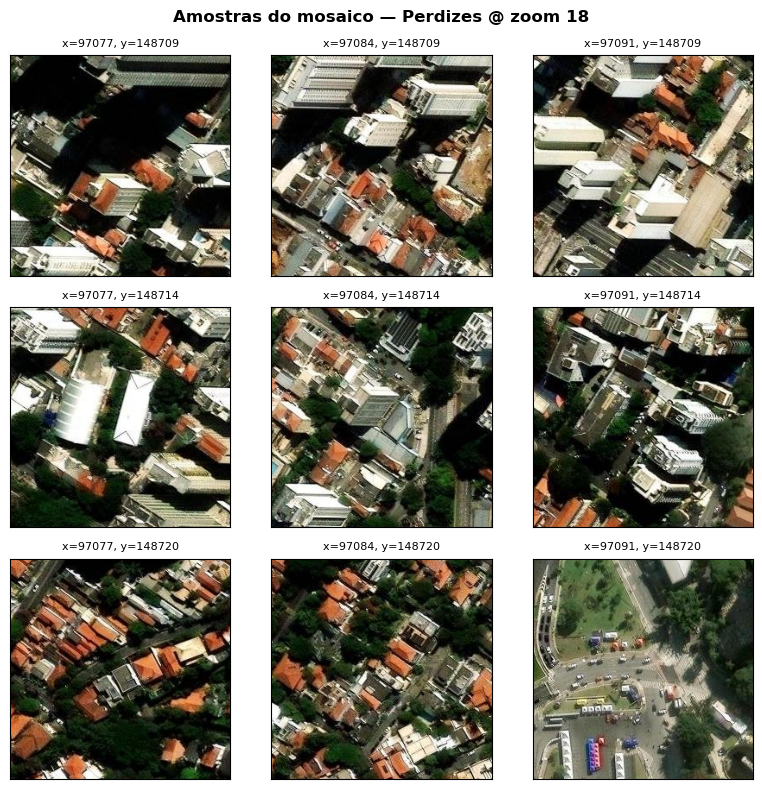

In [5]:
import numpy as np

# escolhe 9 tiles distribuídos uniformemente
xs = np.linspace(x_min, x_max, 3, dtype=int)
ys = np.linspace(y_min, y_max, 3, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, y in enumerate(ys):
    for j, x in enumerate(xs):
        p = OUT_DIR / f"tile_z{ZOOM}_x{x}_y{y}.jpg"
        ax = axes[i, j]
        if p.exists():
            ax.imshow(Image.open(p))
            ax.set_title(f"x={x}, y={y}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"Amostras do mosaico — Perdizes @ zoom {ZOOM}", fontweight="bold")
plt.tight_layout()
plt.savefig("amostra_tiles.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Costura do mosaico completo

Cola todos os tiles num único `.jpg` panorâmico. Para datasets grandes (>2000 tiles) é melhor pular esse passo e manter tudo em tiles individuais — eles já estão prontos para subir no Roboflow.

Mosaico: 3840 x 3072 px  (0 tile(s) faltando)
Arquivos salvos: mosaico_perdizes_preview.jpg, mosaico_perdizes_full.jpg


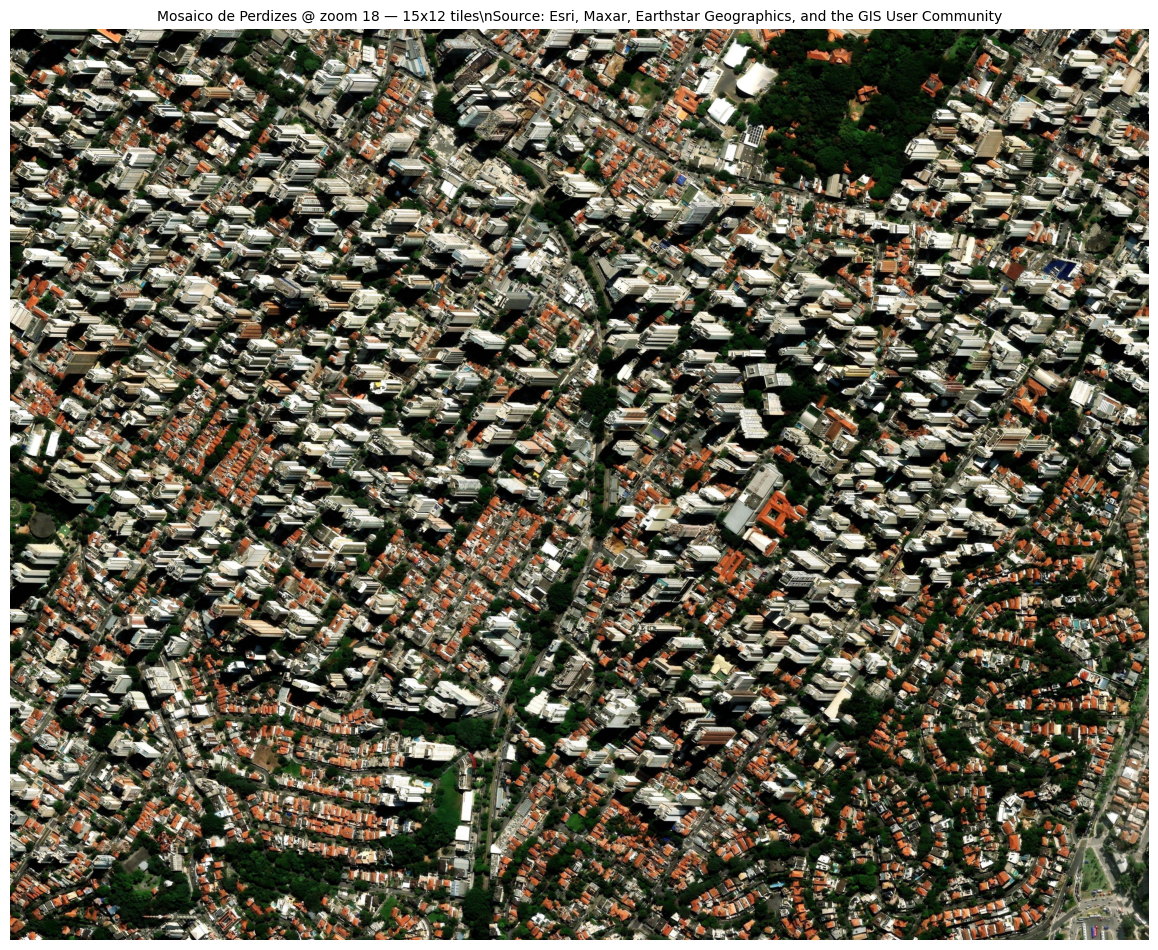

In [6]:
TILE_PX = 256
W = n_cols * TILE_PX
H = n_rows * TILE_PX

mosaico = Image.new("RGB", (W, H), (0, 0, 0))
faltando = 0
for x in range(x_min, x_max + 1):
    for y in range(y_min, y_max + 1):
        p = OUT_DIR / f"tile_z{ZOOM}_x{x}_y{y}.jpg"
        if p.exists():
            tile = Image.open(p)
            mosaico.paste(tile, ((x - x_min) * TILE_PX, (y - y_min) * TILE_PX))
        else:
            faltando += 1

print(f"Mosaico: {W} x {H} px  ({faltando} tile(s) faltando)")

# salva versão reduzida (3000 px de largura) para visualização rápida
preview = mosaico.copy()
preview.thumbnail((3000, 3000))
preview.save("mosaico_perdizes_preview.jpg", quality=85)

# também salva o mosaico completo
mosaico.save("mosaico_perdizes_full.jpg", quality=90)
print("Arquivos salvos: mosaico_perdizes_preview.jpg, mosaico_perdizes_full.jpg")

plt.figure(figsize=(12, 12 * H / W))
plt.imshow(preview)
plt.title(f"Mosaico de Perdizes @ zoom {ZOOM} — {n_cols}x{n_rows} tiles\\n"
          "Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
          fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.savefig("mosaico_perdizes_anotado.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Visualizando a grade de tiles

Esse painel ajuda o aluno a entender quantas células fazem parte do mosaico e qual região cada uma cobre.

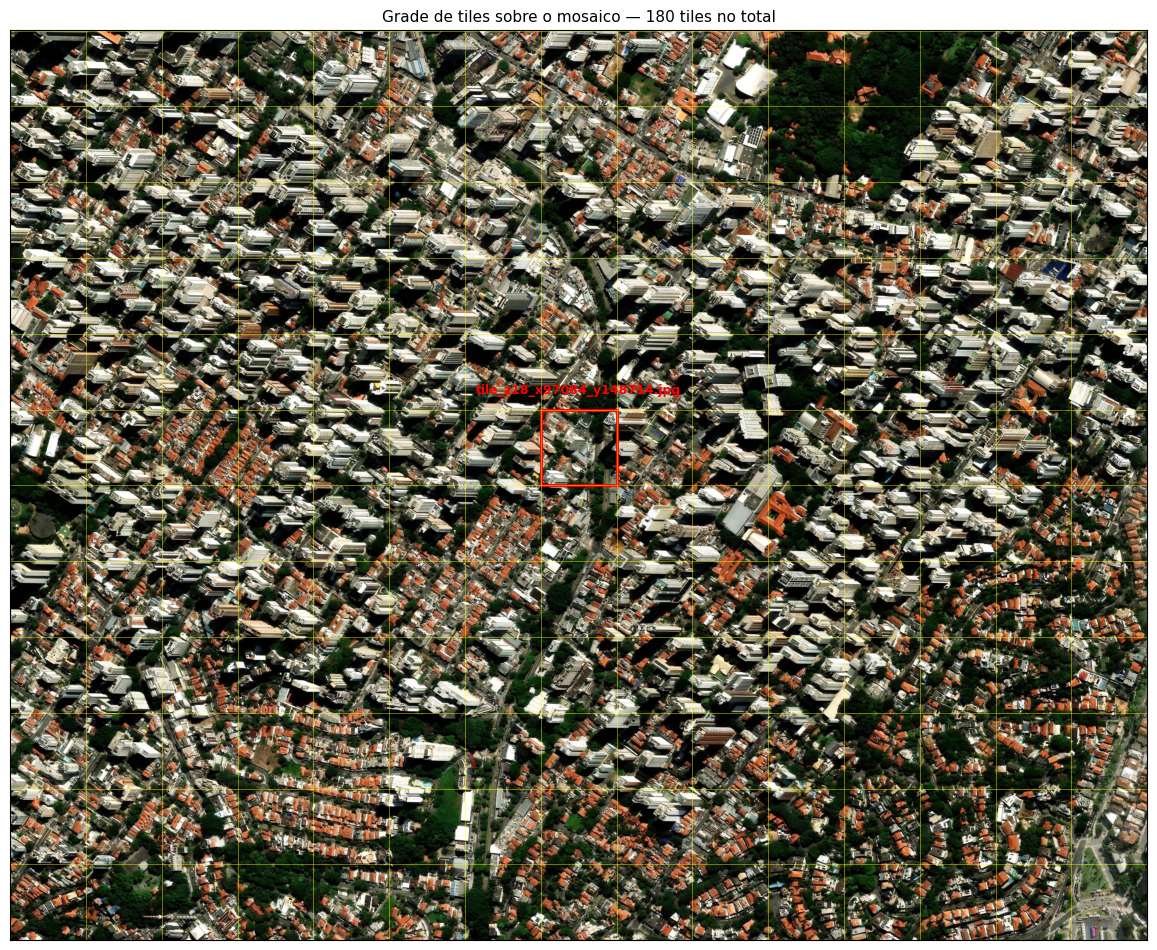

In [7]:
fig, ax = plt.subplots(figsize=(12, 12 * H / W))
ax.imshow(preview)
sx = preview.size[0] / W
sy = preview.size[1] / H
for x in range(x_min, x_max + 1):
    px = (x - x_min) * TILE_PX * sx
    ax.axvline(px, color="yellow", lw=0.5, alpha=0.6)
for y in range(y_min, y_max + 1):
    py = (y - y_min) * TILE_PX * sy
    ax.axhline(py, color="yellow", lw=0.5, alpha=0.6)
# destaca uma célula central
cx, cy = (x_min + x_max) // 2, (y_min + y_max) // 2
ax.add_patch(patches.Rectangle(((cx - x_min) * TILE_PX * sx,
                                (cy - y_min) * TILE_PX * sy),
                               TILE_PX * sx, TILE_PX * sy,
                               linewidth=2, edgecolor="red", facecolor="none"))
ax.text((cx - x_min + 0.5) * TILE_PX * sx,
        (cy - y_min - 0.2) * TILE_PX * sy,
        f"tile_z{ZOOM}_x{cx}_y{cy}.jpg",
        color="red", fontweight="bold", ha="center", fontsize=9)
ax.set_title(f"Grade de tiles sobre o mosaico — {n_total} tiles no total", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("grade_tiles.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Próximos passos

1. **Inspecionar visualmente** os tiles em `mosaico_perdizes/` e descartar os que não têm objetos do alvo (curadoria manual obrigatória).
2. **Subir para o Roboflow**: criar um projeto de *Object Detection*, fazer upload dos tiles aprovados, anotar com bounding boxes.
3. **Repetir** o mesmo notebook para 2-3 bairros adicionais (variar `BBOX`) para garantir diversidade geográfica no conjunto de treino.
4. **Reservar 1 bairro inteiro** sem usar no treino — esse vai ser usado no teste final de generalização (Seção 3.5 da especificação).

### Sobre o uso de imagens

O serviço ESRI World Imagery permite uso para fins **não-comerciais e educacionais** com atribuição. Não redistribua os tiles fora do contexto deste projeto. Para uso institucional ou comercial, considere uma chave ArcGIS Online dedicada.